# 04 · EDA — GeoNames (Localidades Pobladas)
Análisis exploratorio de localidades pobladas de Bolivia y Colombia.  
**Fuente:** GeoNames dump (`download_geonames.py`)  
**Archivo:** `data/external/geonames/geonames_places.csv`

Uso en el pipeline: calcular distancia mínima de cada alerta GFW al centro poblado más cercano,  
como indicador de presión humana sobre el bosque.

## 0. Setup

In [ ]:
# ── Adquisición de datos: descarga desde proxy o lectura local ──
import os, requests
from datetime import date
try:
    from dotenv import load_dotenv
    load_dotenv(Path('..') / '.env')
except ImportError:
    pass

PROXY_URL = os.getenv('DATA_PROXY_URL', '').rstrip('/')
START_DATE = '2022-01-01'
END_DATE = date.today().isoformat()

def ensure_csv(proxy_rel_path, local_path):
    """Descarga proxy_rel_path al local_path. Usa local si falla o no hay proxy."""
    local = Path(local_path)
    if PROXY_URL:
        url = f'{PROXY_URL}/{proxy_rel_path}'
        print(f'⬇ Descargando {url} ...')
        try:
            r = requests.get(url, timeout=120)
            r.raise_for_status()
            local.parent.mkdir(parents=True, exist_ok=True)
            local.write_bytes(r.content)
            print(f'✅ Guardado en {local}')
            return
        except Exception as e:
            print(f'⚠️ Descarga fallida ({e}), usando archivo local.')
    else:
        print(f'⚠️ DATA_PROXY_URL no configurado, usando archivo local.')
    if not local.exists():
        raise FileNotFoundError(f'❌ No se encontró {local} y la descarga falló.')
    print(f'✅ Usando archivo local: {local}')

ensure_csv('external/geonames/geonames_places.csv',
           '../data/external/geonames/geonames_places.csv')

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

GEO_CSV = Path('../data/external/geonames/geonames_places.csv')
RES     = Path('../data/results'); RES.mkdir(parents=True, exist_ok=True)

if not GEO_CSV.exists():
    raise FileNotFoundError(f'Ejecuta scripts/download_geonames.py primero. Esperado: {GEO_CSV}')

df = pd.read_csv(GEO_CSV, dtype={'elevation': 'float32'})
df['latitude']  = pd.to_numeric(df['latitude'],  errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')
df['population'] = pd.to_numeric(df['population'], errors='coerce').fillna(0).astype(int)

print(f'Filas: {len(df):,} | Columnas: {list(df.columns)}')
df.head()

Filas: 61,749 | Columnas: ['geonameid', 'name', 'latitude', 'longitude', 'feature_class', 'feature_code', 'country_code', 'admin1_code', 'population', 'elevation', 'country_iso3']


,geonameid,name,latitude,longitude,feature_class,feature_code,country_code,admin1_code,population,elevation,country_iso3
0,3443961,Yute,-17.48333,-57.96667,P,PPL,BO,8.0,0,NaN,BOL
1,3443962,Yupe,-18.26667,-59.90000,P,PPL,BO,8.0,0,NaN,BOL
2,3443965,Yaré,-18.91667,-59.06667,P,PPL,BO,8.0,0,NaN,BOL
3,3443967,Yacurizal,-16.50000,-58.60000,P,PPL,BO,8.0,0,NaN,BOL
4,3443969,Yacuces,-18.97591,-58.23668,P,PPL,BO,8.0,0,NaN,BOL


## 1. Estructura y calidad

In [2]:
print('Tipos:')
print(df.dtypes)
print('\nNulos:')
print(df.isnull().sum())
print('\nPaíses:')
print(df['country_iso3'].value_counts().to_dict())
print('\nFeature codes (tipos de localidad):')
print(df['feature_code'].value_counts().head(10).to_dict())

Tipos:
geonameid          int64
name                 str
latitude         float64
longitude        float64
feature_class        str
feature_code         str
country_code         str
admin1_code      float64
population         int64
elevation        float32
country_iso3         str
dtype: object

Nulos:
geonameid            0
name                 0
latitude             0
longitude            0
feature_class        0
feature_code         0
country_code         0
admin1_code         47
population           0
elevation        61723
country_iso3         0
dtype: int64

Países:
{'COL': 35945, 'BOL': 25804}

Feature codes (tipos de localidad):
{'PPL': 56839, 'PPLX': 2130, 'PPLL': 1625, 'PPLA2': 1020, 'PPLQ': 39, 'PPLA': 38, 'PPLA4': 34, 'PPLA3': 12, 'PPLF': 4, 'PPLW': 4}


## 2. Distribución geográfica

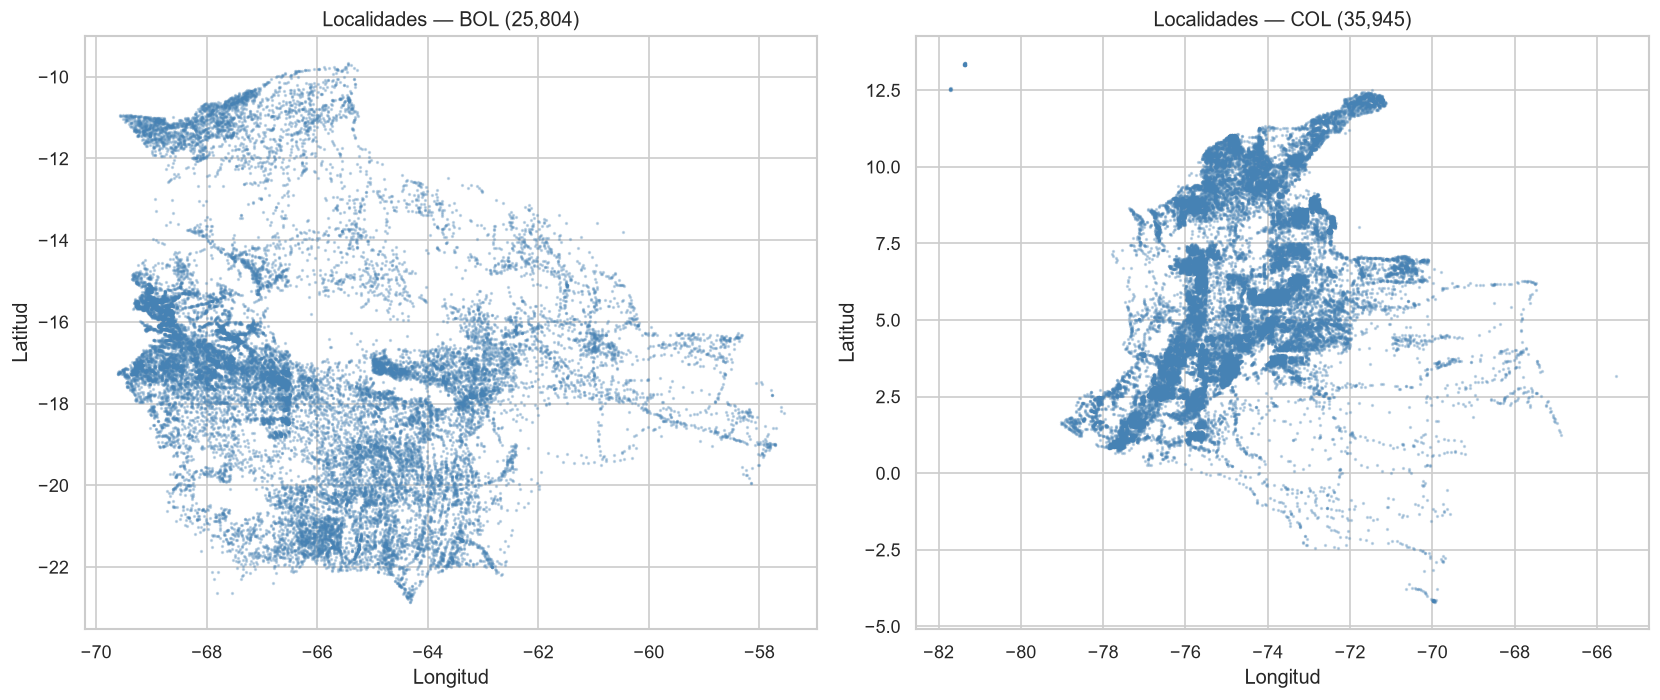

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, country in zip(axes, ['BOL', 'COL']):
    sub = df[df['country_iso3'] == country]
    ax.scatter(sub['longitude'], sub['latitude'],
               s=1, alpha=0.3, c='steelblue')
    ax.set_title(f'Localidades — {country} ({len(sub):,})')
    ax.set_xlabel('Longitud')
    ax.set_ylabel('Latitud')
plt.tight_layout()
plt.savefig(RES / 'eda_geonames_distribucion.png', dpi=120)
plt.show()

## 3. Distribución de población

In [4]:
con_pob = df[df['population'] > 0]
print(f'Localidades con población > 0: {len(con_pob):,} de {len(df):,}')
print('\nEstadísticas de población:')
print(con_pob.groupby('country_iso3')['population'].describe().to_string())

Localidades con población > 0: 1,274 de 61,749

Estadísticas de población:
               count          mean            std   min     25%     50%      75%        max
country_iso3                                                                               
BOL            201.0  37221.288557  200925.463540   5.0   235.0  3037.0  10392.0  2004652.0
COL           1073.0  38077.563840  265485.298131  15.0  2136.0  6683.0  18790.0  7674366.0


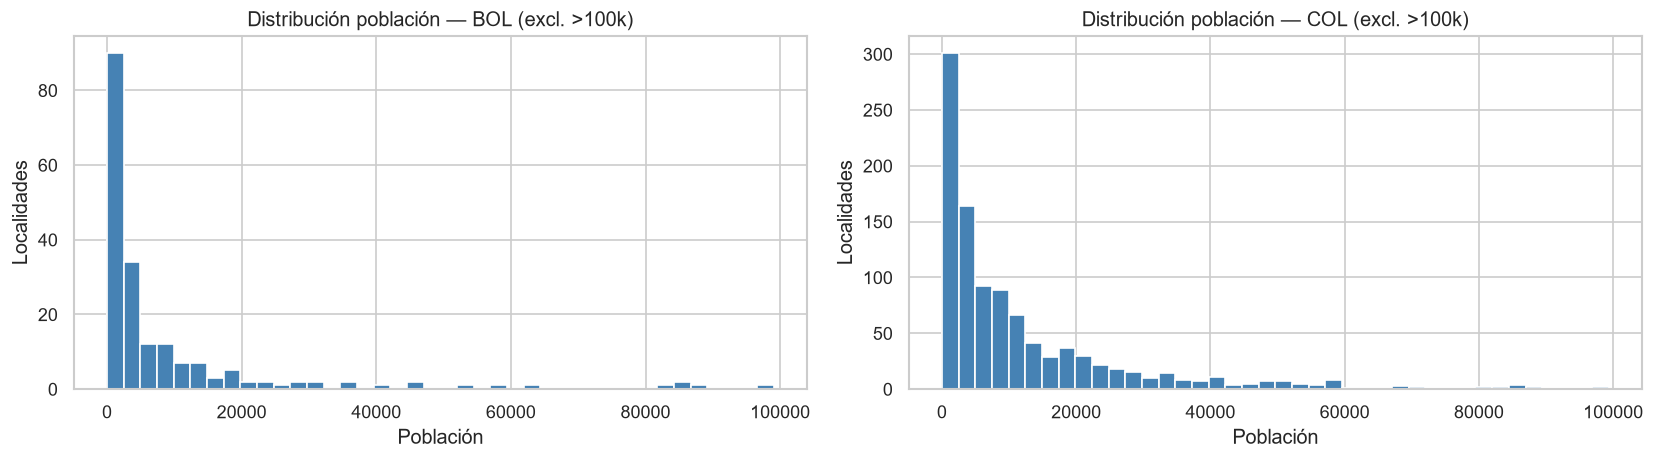

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, country in zip(axes, ['BOL', 'COL']):
    sub = con_pob[(con_pob['country_iso3'] == country) & (con_pob['population'] < 1e5)]
    ax.hist(sub['population'], bins=40, color='steelblue', edgecolor='white')
    ax.set_title(f'Distribución población — {country} (excl. >100k)')
    ax.set_xlabel('Población')
    ax.set_ylabel('Localidades')
plt.tight_layout()
plt.savefig(RES / 'eda_geonames_poblacion.png', dpi=120)
plt.show()

## 4. Top localidades por población

In [6]:
for country in ['BOL', 'COL']:
    top = (df[df['country_iso3'] == country]
           .nlargest(10, 'population')[['name', 'admin1_code', 'population', 'latitude', 'longitude']])
    print(f'\nTop 10 — {country}:')
    print(top.to_string(index=False))


Top 10 — BOL:
                   name  admin1_code  population  latitude  longitude
                 La Paz          4.0     2004652 -16.50000  -68.15000
Santa Cruz de la Sierra          8.0     1831434 -17.78629  -63.18117
             Cochabamba          2.0      841276 -17.38195  -66.15995
                  Sucre          1.0      224838 -19.03332  -65.26274
                  Oruro          5.0      208684 -17.97153  -67.09320
                 Sacaba          2.0      180726 -17.39799  -66.03825
            Quillacollo          2.0      172405 -17.39228  -66.27838
                 Tarija          9.0      159269 -21.53549  -64.72956
                 Potosí          7.0      141251 -19.58361  -65.75306
              Riberalta          3.0       99070 -11.01026  -66.05257

Top 10 — COL:
        name  admin1_code  population  latitude  longitude
      Bogotá         34.0     7674366   4.60971  -74.08175
        Cali         29.0     2392877   3.43054  -76.51990
    Medellín          2

## 5. Hallazgos y decisiones de transformación

| Hallazgo | Decisión |
|----------|----------|
| ~15k–25k localidades por país (feature_class=P) | Filtrar a `population > 0` para reducir ruido |
| Muchas localidades sin dato de población (= 0) | Usar todas para cálculo de distancia mínima, no solo las pobladas |
| Coordenadas completas para todas las filas | Usar lat/lon directamente para cálculo de distancia haversine |
| Granularidad muy fina (aldeas, caseríos) | Calcular distancia al centroide más cercano, sin filtrar por tamaño |
| Datos estáticos (no cambian diariamente) | Descargar una vez; no requiere sincronización incremental |

## Análisis extendido

In [ ]:
# Análisis extendido GeoNames
import warnings, numpy as np
warnings.filterwarnings('ignore')

geo_path_ext = Path('../data/external/geonames/geonames_places.csv')
if geo_path_ext.exists():
    geo_ext = pd.read_csv(geo_path_ext)
    g_cols = {c.lower(): c for c in geo_ext.columns}
    g_name = next((v for k, v in g_cols.items() if k in ('name', 'place_name', 'asciiname')), None)
    g_pop  = next((v for k, v in g_cols.items() if 'pop' in k), None)
    g_cc   = next((v for k, v in g_cols.items() if 'country' in k), None)
    g_lat  = next((v for k, v in g_cols.items() if 'lat' in k), None)
    g_lon  = next((v for k, v in g_cols.items() if 'lon' in k), None)
    if g_cc and g_name and g_pop:
        countries_geo = geo_ext[g_cc].unique()[:2]
        # Top-10 más poblados por país
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        for ax, cc in zip(axes, countries_geo):
            top10 = (geo_ext[geo_ext[g_cc] == cc]
                     .nlargest(10, g_pop)[[g_name, g_pop]])
            ax.barh(top10[g_name], top10[g_pop],
                    color=sns.color_palette('muted')[3])
            ax.invert_yaxis()
            ax.set_title(f'Top-10 lugares más poblados — {cc}')
            ax.set_xlabel('Población')
        plt.suptitle('Localidades más pobladas por país', fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.savefig(RES / 'eda_geonames_extended.png', bbox_inches='tight')
        plt.show()
        print('Guardado: eda_geonames_extended.png')
    if g_lat and g_lon and g_cc:
        # Densidad espacial hexbin
        countries_geo = geo_ext[g_cc].unique()[:2]
        fig2, axes2 = plt.subplots(1, 2, figsize=(14, 6))
        for ax, cc in zip(axes2, countries_geo):
            sub = geo_ext[geo_ext[g_cc] == cc][[g_lat, g_lon]].dropna()
            hb = ax.hexbin(sub[g_lon], sub[g_lat], gridsize=40, cmap='Blues', mincnt=1)
            plt.colorbar(hb, ax=ax, label='Localidades')
            ax.set_title(f'Densidad de localidades — {cc}')
            ax.set_xlabel('Longitud'); ax.set_ylabel('Latitud')
        plt.suptitle('Distribución espacial de centros poblados', fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.savefig(RES / 'eda_geonames_densidad.png', bbox_inches='tight')
        plt.show()
        print('Guardado: eda_geonames_densidad.png')
else:
    print('⚠️ geonames_places.csv no encontrado')